# Travel Reimbursement Approval Agent
## SumitKumar.ipynb

### Overview
An AI-assisted agent that evaluates employee travel reimbursement claims against company policy using Groq LLM with tool calling.

## README

### Setup
1. Install the dependencies from the project environment:
   ```powershell
   pip install -r requirements.txt
   ```
2. Create a `.env` file in the same directory as this notebook:
   ```text
   GROQ_API_KEY=your_groq_api_key
   ```
3. Open this notebook in Jupyter or VS Code with the project Python environment selected.
4. Run the cells from top to bottom. The notebook uses the Groq API, so execution requires an active internet connection and a valid API key.

### Environment Variables
- `GROQ_API_KEY`: Required API key used to create the Groq client.

### How To Run
- Run the dependency cell first if the packages are not installed.
- Restart the kernel and run all cells from top to bottom for a clean demonstration.
- If Groq rate limits a request, wait for the retry message and allow the exponential backoff to complete.
- The final structured-results cell prints one JSON object for each claim.
- The dashboard cell saves `UI_SS_1.png` next to the notebook.

### Outputs
The notebook evaluates five sample claims and returns these fields for every decision:
- `claim_id`
- `decision`
- `approved_amount`
- `deducted_amount`
- `missing_docs`
- `policy_refs`
- `confidence`
- `explanation`
- `tools_used`

### Architecture
- **LLM**: Groq `openai/gpt-oss-20b` at `temperature=0`
- **Pattern**: Manual Groq SDK tool-calling loop
- **Tools**: `lookup_policy`, `check_receipt_compliance`, `calculate_per_diem`, and `check_approval_threshold`
- **Policy Store**: Named constants (`ELIGIBLE`, `INELIGIBLE`, `PER_DIEM`, `RECEIPT_RULES`, `APPROVAL_THRESHOLD`, and `TIMELINES`)
- **Internal helper**: `compute_reimbursible`, which performs deterministic per-diem math and is not LLM-callable

### Key Design Choices
- Policy is not placed in the system prompt; the LLM retrieves policy decisions through tool calls.
- Tools operate one item at a time so the LLM orchestrates the evaluation order.
- Arithmetic is handled in Python to avoid LLM number hallucination.
- Timeliness is pre-computed in Python and passed in the claim JSON.
- Parse and runtime failures fall back to `MANUAL_REVIEW`.

In [39]:
%pip install groq python-dotenv matplotlib numpy --quit

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\Sumit don\travel-reimbursement-agent\venv\Scripts\python.exe -m pip 
install [options] <requirement specifier> [package-index-options] ...
  c:\Users\Sumit don\travel-reimbursement-agent\venv\Scripts\python.exe -m pip 
install [options] -r <requirements file> [package-index-options] ...
  c:\Users\Sumit don\travel-reimbursement-agent\venv\Scripts\python.exe -m pip 
install [options] [-e] <vcs project url> ...
  c:\Users\Sumit don\travel-reimbursement-agent\venv\Scripts\python.exe -m pip 
install [options] [-e] <local project path> ...
  c:\Users\Sumit don\travel-reimbursement-agent\venv\Scripts\python.exe -m pip 
install [options] <archive url/path> ...

no such option: --quit


In [40]:
import os, json, re, time
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from groq import Groq
from dotenv import load_dotenv

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY"), timeout=120.0)
MODEL = 'openai/gpt-oss-20b'
print('Ready, Model:', MODEL)

Ready, Model: openai/gpt-oss-20b


In [41]:
# ---------------------- Policy Rules --------------------------------------

ELIGIBLE = {
    'items': [
        'Airfare',
        'Lodging (hotel room charges)',
        'Meals',
        'Ground Transportation (taxi, rideshare, traisn, rental car, parking)',
        'Conference/registration Fees',
    ],
    'policy': 'POL-CAT-01'
}

INELIGIBLE = {
    'items': [
        'Alocohol and minibar',
        'Spa, gym, and personal entertainment',
        'In-room movies',
        'Personal shopping, gifts',
        'Traffic fines, penalties, and late fees',
        'Any personal (non-business) expense'
    ],
    'policy': 'POL-CAT-02'
}

PER_DIEM = [
    {
        'type': 'Meals', 'limit': 75, 'unit': 'per_day',
        'description': 'Maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.',
        'policy': 'POL-PD-01'
    },
    {
        'type': 'Lodging', 'limit': 200, 'unit': 'per_night',
        'description': 'Maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.',
        'policy': 'POL-PD-02'
    },
    {
        'type': 'Ground Transport', 'limit': 50, 'unit': 'per_day',
        'description': 'Maximum $50 per day. Amounts above the daily cap are deducted.',
        'policy': 'POL-PD-03'
    },
    {
        'type': 'Airfare class', 'limit': None, 'unit': None,
        'description': 'Only economy class airfare is reimbursible. Business/first-class fares must be routed to manual Review (pre-approavl may exist).',
        'policy': 'POL-AIR-01'
    }
]

RECEIPT_RULES = [
    {
        'type': 'Amount threshold', 'threshold': 25, 'always_required': ['airfare', 'lodging'],
        'description': 'Any single lint item greater than $25 requires an attached receipt. Airfare and lodging always requires a receipt regardless of amount.',
        'policy': 'POL-RCT-01'
    },
    {
        'type': 'Missing receipt', 'action': 'MANUAL_REVIEW',
        'description': 'If a receipt is missing for an items that requires one, the claim is routed to Manual Review.',
        'policy': 'POL-RCT-02'
    }
]

APPROVAL_THRESHOLD = [
    {
        'type': 'Auto-approve', 'max': 500, 'manual_review': False,
        'description': 'Total <= $500: may be auto-approved by the agent if fully compliant.',
        'policy': 'POL-APR-01'
    },
    {
        'type': 'Manager', 'max': 2000, 'manual_review': False,
        'description': 'Total > $500 and <= $2000: eligible  for approval, treated as approvable when fully compliant.',
        'policy': 'POL-APR-02'
    },
    {
        'type': 'Director/ManualReview', 'max': float('inf'), 'manual_review': True,
        'description': "Total > $2000: exceeds the agent's autoapproval authority and must be routed to Manual Review.",
        'policy': 'POL-APR-03'
    }
]

TIMELINES = {
    'days': 30,
    'description': 'Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.',
    'policy': 'POL-TIME-01'
}

print(f'Policy loaded: {len(ELIGIBLE["items"])} eligible, {len(INELIGIBLE["items"])} ineligible categories')

Policy loaded: 5 eligible, 6 ineligible categories


In [42]:
# --------------------- Internal helper (compute reimbusable) --------------------------

def compute_reimbursible(amount: float, limit: float, unit: str, trip_days: int, trip_nights: int) -> dict:
    """Deterministic per-diem math. Called by calculate_per_diem internally."""
    units = trip_nights if unit == 'per_night' else trip_days
    cap = limit * units
    approved = min(amount, cap)
    deducted = round(amount - approved, 2)
    return {'approved': approved, 'deducted': deducted, 'cap': cap}

# ------------------------------------- Tool 1 -----------------------------------

def lookup_policy(category: str) -> dict:
    """Fetch eligibility for a claim item category."""
    cat = category.lower().strip()
    cat_parts = cat.replace('_', ' ').split()

    def _matches(text: str) -> dict:
        t = text.lower()
        return cat in t or any(p in t for p in cat_parts if len(p) > 4)

    for item in ELIGIBLE['items']:
        if _matches(item):
            return {'eligible': True, 'policy': ELIGIBLE['policy']}

    for item in INELIGIBLE['items']:
        if _matches(item):
            return {'eligible': False, 'policy': INELIGIBLE['policy']}

    return {'eligible': 'unknown', 'notw': 'Category not in policy - route to MANUAL_REVIEW'}

# --------------------------- Tool 2 --------------------------------------

def check_receipt_compliance(category: str, amount: float, receipt_attached: bool) -> dict:
    """Check receipt requirements for a single claim item."""
    cat = category.lower().strip()
    rule = RECEIPT_RULES[0]
    missing_rule = RECEIPT_RULES[1]
    needs = cat in rule['always_required'] or amount > rule['threshold']
    status = 'PASS' if (not needs or receipt_attached) else 'FAIL'

    result = {
        'category': cat, 'amount': amount, 'receipt_required': needs, 
        'status': status, 'policy_ref': rule['policy']
    }

    if status == 'FAIL':
        result['action'] = missing_rule['action']
        result['action_policy_ref'] = missing_rule['policy']

    return result

# ----------------------------- Tool 3 ---------------------------------

def calculate_per_diem(category: str, description: str, amount: float, trip_days: int, trip_nights: int) -> dict:
    """Compute approved and deducted amounts for a single claim item."""
    cat = category.lower().strip()
    desc = description.lower()

    # Ineligible check
    if any(cat in e.lower() for e in INELIGIBLE['items']):
        return {'category': cat, 'claimed': amount, 'approved': 0.0, 'deducted': amount, 
                'status': 'INELIGIBLE', 'policy_ref': INELIGIBLE['policy']}

    per_diem = next((p for p in PER_DIEM if cat in p['type'].lower()), None)

    # No per-diem rule (e.g. conference_fees) - full approval
    if per_diem is None:
        return {'category': cat, 'claimed': amount, 'approved': amount, 'deducted': 0.0, 
                'status': 'PASS', 'policy_ref': None}

    # Airfare class check
    if per_diem['limit'] is None:
        if 'business' in desc or 'first' in desc:
            return {'category': cat, 'claimed': amount, 'approved': 0.0, 'deducted': 0.0, 
                    'status': 'MANUAL_REVIEW',
                    'reason': 'Business/first-class airfare requires manual review (pre-approavl may exist)',
                    'policy_ref': per_diem['policy']}
        return {'category': cat, 'claimed': amount, 'approved': amount, 'deducted': 0.0, 
                'status': 'PASS', 'policy_ref': per_diem['policy']}

    # Apply per-diem cap
    c = compute_reimbursible(amount, per_diem['limit'], per_diem['unit'], trip_days, trip_nights)
    return {
        'category': cat, 'claimed': amount, 'approved': c['approved'], 'deducted': c['deducted'], 
        'cap': c['cap'], 'status': 'CAP_EXCEDED' if c['deducted'] > 0 else 'PASS', 
        'policy_ref': per_diem['policy']
    }

# ---------------- Tool 4 ------------------------------------

def check_approval_threshold(total_reimbursable: float) -> dict:
    """Determine approval tier from total reimbursible amount."""
    if total_reimbursable <= 500:
        tier = APPROVAL_THRESHOLD[0]
    elif total_reimbursable <= 2000:
        tier = APPROVAL_THRESHOLD[1]
    else:
        tier = APPROVAL_THRESHOLD[2]

    return {
        'total': total_reimbursable, 'tier': tier['type'], 
        'manual_review': tier['manual_review'], 'policy_ref': tier['policy']
    }

TOOL_REGISTRY = {
    'lookup_policy': lookup_policy,
    'check_receipt_compliance': check_receipt_compliance,
    'calculate_per_diem': calculate_per_diem,
    'check_approval_threshold': check_approval_threshold
}

print('Tools defined:', list(TOOL_REGISTRY.keys()))


Tools defined: ['lookup_policy', 'check_receipt_compliance', 'calculate_per_diem', 'check_approval_threshold']


In [43]:
# ------------------------ Tools Schema -----------------------

TOOL_SCHEMA = [
    {
        'type': 'function',
        'function': {
            'name': 'lookup_policy', 
            'description': 'Fetch eligibility for a claim item category. Call this for each unique category before other tools.',
            'parameters': {
                'category': {'type': 'string', 'description': 'Claim item category, e.g. airfare, lodging, meals, spa, minibar'}
            },
            'required': ['category']
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'check_receipt_compliance', 
            'description': 'Check if a single claim item meets receipt requirements. Call once per item.',
            'parameters': {
                'type': 'object',
                'properties': {
                    'category': {'type': 'string', 'description': 'Item category'},
                    'amount': {'type': 'number', 'description': 'Item amount in USD'},
                    'receipt_attached': {'type': 'boolean', 'description': 'Whether a receipt is attached for this item'}
                }
            },
            'required': ['category', 'amount', 'receipt_attached']
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'calculate_per_diem', 
            'description': 'Compute approved and deducted amounts for a single claim item. Call once per item.',
            'parameters': {
                'type': 'object',
                'properties': {
                    'category': {'type': 'string', 'description': 'Item category'},
                    'description': {'type': 'string', 'description': 'Item description'},
                    'amount': {'type': 'number', 'description': 'Item amount in USD'},
                    'trip_days': {'type': 'number', 'description': 'Number of trip days'},
                    'trip_nights': {'type': 'number', 'description': 'Number of trip nights'}
                }
            },
            'required': ['category', 'description', 'amount', 'trip_days', 'trip_nights']
        }
    },
    {
        'type': 'function',
        'function': {
            'name': 'check_approval_threshold', 
            'description': 'Determine approval tier from total reimbursable amount. Call once after summing all calculate_per_diem calls results.',
            'parameters': {
                'total_reimbursable': {'type': 'number', 'description': 'Sum of all approved amounts in USD'}
            },
            'required': ['total_reimbursable']
        }
    },
]

print('Tool schema defined:', len(TOOL_SCHEMA), 'tools')

Tool schema defined: 4 tools


In [ ]:
SYSTEM_PROMPT = '''You are a Travel Reimbursement Approavl Agent. Evaluate employee travel claims againt company policy.

You have NO policy rules, limits, or eligibility data memorized.
All policy data must be fetched and applied by the tools internally.

TOOLS:
- lookup_policy(category)                                                         Check if a category is eligible for reimbursement. Call first for each item.
- check_receipt_compliance(category, amount, receipt_attached)                    Validate receipt requirement for one item
- calculate_per_diem(category, description, amount, trip_days, trip_nights)       Compute approved/deducted amounts for one item
- check_approval_threshold(total_reimbursable)                                    Determine approval tier from total approved amount

IMPORTANT TOOL-NAME RULE:
Use tool names exactly as listed above. Never add punctuation, spaces, ellipses, or parentheses.
For example, use check_receipt_compliance, not check_receipt_compliance... or check_receipt_compliance().

PROCESS (follow in this exact order):
1. For each unique category in the claim items, call lookup_policy(category)
2. If lookup_policy returns eligible=false, mark that item INELIGIBLE, that item contribute approved=0, deducted=amount - skip step 3 and 4 for it
3. For each ELIGIBLE item, call check_receipt_compliance(category, amount, receipt_attached)
4. For each ELIGIBLE item, where check_receipt_compliance returned status=FAIL, skip calculate_per_diem - that item contributes approved=0, deducted=0
   If check_receipt_compliance returned status=PASS, call calculate_per_diem(category, description, amount, trip_days, trip_nights)
5. Sum approved amounts from all calculate_per_diem results
6. Call check_approval_threshold(total_reimbursable) with that sum
7. Returns the final decision as a JSON object

TIMELINESS: The claim JSON includes submission_timely (tru/false). If false, route to MANUAL_REVIEW.

DECISION RULES:
- APPROVE    all items eligible, all receipts present, within caps, total in approval tier
- PARTIAL_APPROVE  valid claim but some amounts exceed per-diem caps
- REJECT   all items ineligible, nothing reimbursible
- MANUAL_REVIEW   missing receipt, business-class airfare, total > $2000, late submission, unknown category, or ambiguity

Prefer MANUAL_REVIEW over forcing an uncertain decision

Return ONLY a valid JSON object with exactly these fields, no extra text:
{
    "claim_id": string,
    "decision": "APPROVE" | "PARTIAL_APPROVE" | "REJECT" | "MANUAL_REVIEW",
    "approved_amount": number,
    "deducted_amount": number,
    "missing_docs": [list of strings],
    "policy_refs": [list of policy IDs cited]
    "confidence": number between 0.0 and 1.0,
    "explanation": string,
    "tools_used": [list of tool names called]
}
'''

print('System prompt ready')

System prompt ready


In [45]:
#  -------------------- Claims Data --------------------------

def _trip_meta(trip_start: str, submitted: str):
    days = (date.fromisoformat(submitted) - date.fromisoformat(trip_start)).days
    timely = days <= TIMELINES['days']
    return days, timely

CLAIMS = [
    {
        'claim_id': 'CLM-001', 'employee': 'A. Rivera',
        'business_purpose': 'Attend 2-day industry confernece',
        'trip_start': '2026-06-10', 'trip_end': '2026-06-12', 'submitted': '2026-06-20',
        'trip_days': 3, 'trip_nights': 2,
        'items': [
            {'category': 'airfare', 'description': 'Round-trip economy airfare', 'amount': 420.00, 'receipt_attached': True},
            {'category': 'lodging', 'description': 'Hotel, 2 nights @ $180', 'amount': 360.00, 'receipt_attached': True},
            {'category': 'meals', 'description': 'Meals, 3 days @ ~$60/day', 'amount': 180.00, 'receipt_attached': True},
            {'category': 'conference_fees', 'description': 'Conference registration', 'amount': 150.00, 'receipt_attached': True},
        ],
        'total_claimed': 1110.00
    },
    {
        'claim_id': 'CLM-002', 'employee': 'B. Osei',
        'business_purpose': 'Weekend hotel stay',
        'trip_start': '2026-06-14', 'trip_end': '2026-06-15', 'submitted': '2026-06-25',
        'trip_days': 1, 'trip_nights': 1,
        'items': [
            {'category': 'spa', 'description': 'Hotel spa package', 'amount': 300.00, 'receipt_attached': True},
            {'category': 'minibar', 'description': 'In-room minibar', 'amount': 80.00, 'receipt_attached': True},
        ],
        'total_claimed': 380.00
    },
    {
        'claim_id': 'CLM-003', 'employee': 'C. Nakamura',
        'business_purpose': 'Client site visit',
        'trip_start': '2026-06-08', 'trip_end': '2026-06-10', 'submitted': '2026-06-22',
        'trip_days': 2, 'trip_nights': 2,
        'items': [
            {'category': 'airfare', 'description': 'Round-trip economy airfare', 'amount': 300.00, 'receipt_attached': True},
            {'category': 'lodging', 'description': 'Hotel, 2 nights @ $250', 'amount': 500.00, 'receipt_attached': True},
            {'category': 'meals', 'description': 'Meals, 3 days @ ~$70/day', 'amount': 140.00, 'receipt_attached': True},
        ],
        'total_claimed': 940.00
    },
    {
        'claim_id': 'CLM-004', 'employee': 'D. Fisher',
        'business_purpose': 'International vendor negotiation',
        'trip_start': '2026-06-16', 'trip_end': '2026-06-18', 'submitted': '2026-06-28',
        'trip_days': 3, 'trip_nights': 3,
        'items': [
            {'category': 'airfare', 'description': 'Business-class international airfare', 'amount': 2400.00, 'receipt_attached': True},
            {'category': 'lodging', 'description': 'Hotel, 3 nights', 'amount': 600.00, 'receipt_attached': False},
        ],
        'total_claimed': 3000.00
    },
    {
        'claim_id': 'CLM-005', 'employee': 'E. Haddad',
        'business_purpose': 'Client dinner / business development',
        'trip_start': '2026-06-11', 'trip_end': '2026-06-11', 'submitted': '2026-06-24',
        'trip_days': 1, 'trip_nights': 0,
        'items': [
            {'category': 'meals', 'description': 'Client dinner for 4 (business development)', 'amount': 220.00, 'receipt_attached': False},
        ],
        'total_claimed': 220.00
    }
]

for c in CLAIMS:
    days, timely = _trip_meta(c['trip_start'], c['submitted'])
    c['days_since_expense'] = days
    c['submission_timely'] = timely

print(f'{len(CLAIMS)} claims loaded:')
for c in CLAIMS:
    print(f'  {c["claim_id"]} | {c["employee"]:15} | ${c["total_claimed"]:8.2f} | timely={c["submission_timely"]} | items={len(c["items"])}')

5 claims loaded:
  CLM-001 | A. Rivera       | $ 1110.00 | timely=True | items=4
  CLM-002 | B. Osei         | $  380.00 | timely=True | items=2
  CLM-003 | C. Nakamura     | $  940.00 | timely=True | items=3
  CLM-004 | D. Fisher       | $ 3000.00 | timely=True | items=2
  CLM-005 | E. Haddad       | $  220.00 | timely=True | items=1


In [46]:
# -------------------- Agent loop ---------------------------------

def _normalize(decision: dict) -> dict:
    """Guarantee approved/deducted are 0 for MANUAL_REVIEW - human makes final call."""
    if decision.get('decision') == 'MANUAL_REVIEW':
        decision['approved'] = 0.0
        decision['deducted'] = 0.0
    return decision

def process_claim(claim: dict) -> dict:
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(claim, indent=2)}
    ]
    tools_used = []

    print(f'\n{"="*60}')
    print(f'Processing {claim["claim_id"]} - {claim["employee"]})')
    print(f'{"="*60}')

    for attempt in range(15): # Safety cap on iterations
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                tools=TOOL_SCHEMA,
                tool_choice='auto',
                temperature=0,
            )
        except Exception as api_err:
            err_body = getattr(api_err, 'body', {}) or {}
            failed_gen = err_body.get('error', {}).get('failed_generation', '')
            if failed_gen:
                try:
                    raw = json.loads(failed_gen)
                    decision = raw.get('arguments', raw)
                    if 'decision' in decision:
                        decision['tools_used'] = list(dict.fromkeys(tools_used))
                        decision = _normalize(decision)
                        print(f'\n Decision : {decision["decision"]}')
                        print(f' Approved : ${decision["approved_amount"]}')
                        print(f' Deducted : ${decision["deducted_amount"]}')
                        return decision
                except Exception:
                    pass
            err_str = str(api_err)
            if 'timed out' in err_str.lower() or 'timeout' in err_str.lower():
                print('Timeout, retrying...')
                continue
            if '429' in err_str or 'rate_limit' in err_str.lower()  or 'rate limit' in err_str.lower():
                m = re.search(r'try again in ([\d.]+)(ms|s)', err_str)
                server_wait = (float(m.group(1)) / 1000.0) if m and m.group(2) == 'ms' else (float(m.group(1)) if m else 0.0)
                backoff_wait = min(5.0 * (2 ** attempt), 60.0)
                wait = max(server_wait, backoff_wait)
                print(f'Rate limit, waiting {wait:.1f}s then retrying...')
                time.sleep(wait)
                continue
            print(f' API error: {err_str}')
            break

        choice = response.choices[0]

        if choice.finish_reason == 'tool_calls':
            messages.append(choice.message)

            for tc in choice.message.tool_calls:
                name = tc.function.name
                args = json.loads(tc.function.arguments)
                print(f' -> {name}({args})')

                fn = TOOL_REGISTRY.get(name)
                result = fn(**args) if fn else {'error': f'Unknown tool: {name}'}
                print(f'   <- {result}')

                tools_used.append(name)
                messages.append({
                    'role': 'tool',
                    'tool_call_id': tc.id,
                    'content': json.dumps(result)
                })

        elif choice.finish_reason == 'stop':
            content = choice.message.content.strip()

            # Strip markdown code fences if LLM wraps the JSON
            if content.startswith('~~~'):
                lines = content.split('\n')
                content = '\n'.join(lines[1:])
            if content.endswith('~~~'):
                content.rsplit('~~~', 1)[0]
            content = content.strip()

            try:
                decision = json.loads(content)
                decision['tools_used'] = list(dict.fromkeys(tools_used))
                decision = _normalize(decision)
                print(f'\n Decision : {decision["decision"]}')
                print(f' Approved : ${decision["approved_amount"]}')
                print(f' Deducted : ${decision["deducted_amount"]}')
                return decision
            except json.JSONDecodeError as e:
                print(f' JSON parse error: {e}')
                break

        else:
            print(f' Unexpected finish_reason: {choice.finish_reason}')
            break

    # Fallback - always route to MANUAL_REVIEW on failure
    print(f' Fallback: MANUAL_REVIEW')
    return {
        'claim_id': claim.get('claim_id', 'UNKNOWN'),
        'decision': 'MANUAL_REVIEW',
        'approved_amount': 0,
        'deducted_amount': 0,
        'missing_docs': [],
        'policy_refs': [],
        'confidence': 0.0,
        'explanation': 'Agent could not determine a decision - routing to manual review',
        'tools_used': list(dict.fromkeys(tools_used))
    }

print('process_claim ready')

process_claim ready


In [47]:
# ---------- Run All Claims -----------------------------

results = []
for claim in CLAIMS:
    result = process_claim(claim)
    results.append(result)

print(f'\n{"="*60}')
print(f'All {len(results)} claims processed')
print(f'{"="*60}')
for r in results:
    print(f' {r["claim_id"]} -> {r["decision"]:20} approved=${r["approved_amount"]:>8} deducted=${r["deducted_amount"]}')


Processing CLM-001 - A. Rivera)
Rate limit, waiting 5.0s then retrying...
Rate limit, waiting 10.0s then retrying...


KeyboardInterrupt: 

ValueError: max() iterable argument is empty

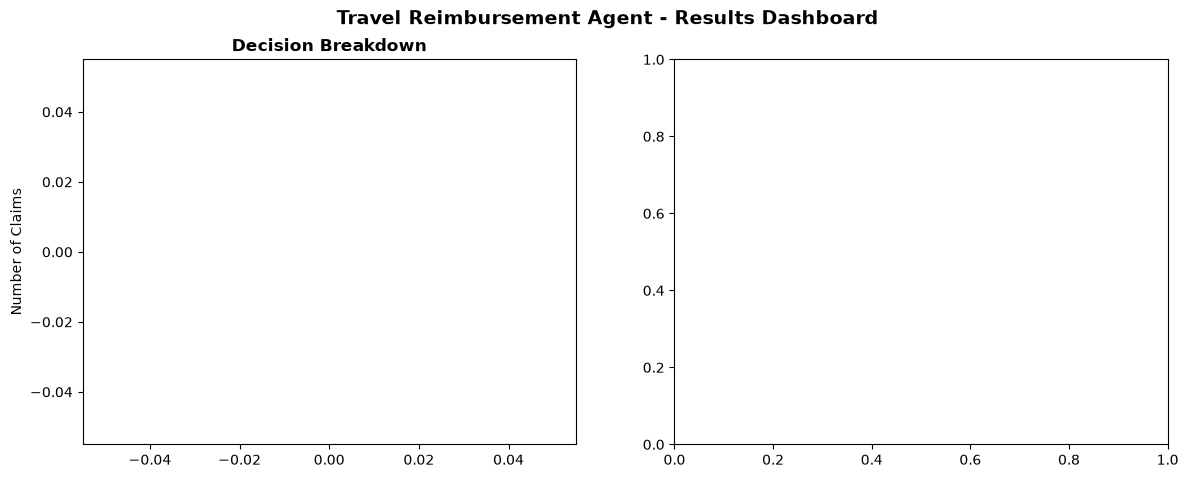

In [10]:
## Dashboard

DECISION_COLORS = {
    'APPROVE': '#2ecc71',
    'PARTIAL_APPROVE': '#f39c12',
    'REJECT': '#e74c3c',
    'MANUAL_REVIEW': '#3498db'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Travel Reimbursement Agent - Results Dashboard', fontsize=14, fontweight='bold')

# ------------ Chart 1: Decision breakdown -------------------

decision_counts = {}
for r in results:
    d = r['decision']
    decision_counts[d] = decision_counts.get(d, 0) + 1

labels = list(decision_counts.keys())
counts = list(decision_counts.values())
colors = [DECISION_COLORS.get(d, '#95a5a6') for d in labels]

bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Decision Breakdown', fontweight='bold')
axes[0].set_ylabel('Number of Claims')
axes[0].set_ylim(0, max(counts) + 1.2)
axes[0].tick_params(axis='x', rotation=10)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(count), ha='center', va='bottom', fontweight='bold')

# ------------------ Chart 2: Approved vs Dedicted per claim -----------------

claim_ids = [r['claim_id'] for r in results]
approved = [r['approved_amount'] for r in results]
deducted = [r['deducted_amount'] for r in results]
x = np.arange(len(claim_ids))
width = 0.35

axes[1].bar(x - width / 2, approved, width, label='Approved', color='#2ecc71', edgecolor='white')
axes[1].bar(x + width / 2, deducted, width, label='Deducted', color='#e74c3c', edgecolor='white')
axes[1].set_title('Approved vs Deducted per Claim (USD)', fontweight='bold')
axes[1].set_ylabel('Amount (USD)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(claim_ids)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.savefig('UI_SS_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as UI_SS_1.png')

In [ ]:
# ------------- Final Structured Output ---------------

print(json.dumps(results, indent=2))

## Design Notes & Reasoning

### Why LLM + Tool Calling (not Langgraph or CrewAI)
The assignment explicitely requires *"showing how LLM decides when to use tools."* In Langgraph the graph decides which nodes run - not the LLM. A manual Groq tool-calling loop keeps the LLM as the orchestrator: it reads each claim, decides which tools to call and in what order, and synthesizes the final decision. CrewAI is designed for multi-agent collaboration, not a single-agent pipeline - wrong tool for this problem.

### One Item Per Tool Call
`check_receipt_compliance` and `calculate_per_diem` accept one item at a time. This forces the LLM to make per-item calls, demonstrataing active orchestration. It also allows the LLM to reason per-item - for example, stoping further checks early if item is ineligible or a critical MANUAL_REVIEW is found.

### compute_reimbursible Is an internal Helper
Per-diem arithmetic (`min(500, 200x2) = 400`) is deterministic. Delegating this to the LLM risks number hallucination. `compute_reimbursible` is a pure Python function called by `calculate_per_diem` internally - the LLM never calls it directly.

### Timeliness Pre-computed in Python
POL-TIME-01 (30-day window) is a simple date substraction. It is computed in Python and passed as `submission_timely` in the claim JSON. The LLM reads this fact and routes to MANUAL_review If False - no seperate tool call needed.

### Assumption
- `trip_days` and `trip_nights` are derived from the claim description (e.g. "2 nights @ $250" -> trip_nights=2)
- Meal cap ($75/day) is per-day total , not per-person - clm-005 group dinner is treated as one daily meal event
- Business-class airfare -> MANUAL_REVIEW, not REJECT - pre-approval may exist (POL-AIR-01)
- CLM-002 (spa + minibar) -> REJECT - 100% of items are ineligible with nothing reimbursable
- `approved_amount` and `deducted_amount` are set to 0 for MANUAL_REVIEW cases - a human reviwer makes the final call

### What I Would Improve Next
- Add a `claim_duplicate` tool that queries a claims history database (genuine external data the LLM cannot infer)
- Store policy in a JSON/database file to rule updates requies no code changes
- Add Lngsmith tracing for audit trail and tool-call quality evaluation over time
- Build UI for interactive claim submission and real-time agent traces
- Add evaluation harness comparing agent decisions against ground-truth labels using LLM-as-judge